In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"E:\vs\base_module1\Taxpayer Risk Classification\dataset\tax_risk_dataset.csv")

df.head()

,Taxpayer_ID,Revenue,Expenses,Tax_Liability,Tax_Paid,Late_Filings,Compliance_Violations,Industry,Profit,Tax_Compliance_Ratio,Audit_Findings,Audit_to_Tax_Ratio,Risk_Label
0,1,1149014.25,979871.09,39872.33,28921.92,2,1,Finance,169143.16,0.73,0,0.0,High
1,2,958520.71,884926.74,47832.22,39396.15,1,1,Retail,73593.97,0.82,0,0.0,Medium
2,3,1194306.56,711926.07,38113.70,43863.94,4,0,Manufacturing,482380.49,1.15,3,0.0,High
3,4,1456908.96,570612.64,45380.58,66876.88,4,2,Finance,886296.32,1.47,1,0.0,High
4,5,929753.99,839644.66,21595.78,53565.53,0,0,Tech,90109.33,2.48,2,0.0,Low


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 13


In [5]:
df.columns

Index(['Taxpayer_ID', 'Revenue', 'Expenses', 'Tax_Liability', 'Tax_Paid',
       'Late_Filings', 'Compliance_Violations', 'Industry', 'Profit',
       'Tax_Compliance_Ratio', 'Audit_Findings', 'Audit_to_Tax_Ratio',
       'Risk_Label'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Taxpayer_ID            1000 non-null   int64  
 1   Revenue                1000 non-null   float64
 2   Expenses               1000 non-null   float64
 3   Tax_Liability          1000 non-null   float64
 4   Tax_Paid               1000 non-null   float64
 5   Late_Filings           1000 non-null   int64  
 6   Compliance_Violations  1000 non-null   int64  
 7   Industry               1000 non-null   str    
 8   Profit                 1000 non-null   float64
 9   Tax_Compliance_Ratio   1000 non-null   float64
 10  Audit_Findings         1000 non-null   int64  
 11  Audit_to_Tax_Ratio     1000 non-null   float64
 12  Risk_Label             1000 non-null   str    
dtypes: float64(7), int64(4), str(2)
memory usage: 113.3 KB


In [7]:
df.isnull().sum()

Taxpayer_ID              0
Revenue                  0
Expenses                 0
Tax_Liability            0
Tax_Paid                 0
Late_Filings             0
Compliance_Violations    0
Industry                 0
Profit                   0
Tax_Compliance_Ratio     0
Audit_Findings           0
Audit_to_Tax_Ratio       0
Risk_Label               0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.describe()

,Taxpayer_ID,Revenue,Expenses,Tax_Liability,Tax_Paid,Late_Filings,Compliance_Violations,Profit,Tax_Compliance_Ratio,Audit_Findings,Audit_to_Tax_Ratio
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.0
mean,500.500000,1.005800e+06,7.141672e+05,50087.513200,47812.807910,2.029000,1.033000,2.916324e+05,1.077180,4.396000,0.0
std,288.819436,2.937648e+05,1.994909e+05,14751.814482,10271.325437,1.415685,0.812756,3.617036e+05,0.617086,2.927414,0.0
min,1.000000,2.761980e+04,1.119223e+05,4707.320000,18705.510000,0.000000,0.000000,-7.801314e+05,0.240000,0.000000,0.0
25%,250.750000,8.057229e+05,5.787517e+05,40280.002500,40625.797500,1.000000,0.000000,4.100442e+04,0.767500,2.000000,0.0
50%,500.500000,1.007590e+06,7.126154e+05,49996.240000,48001.845000,2.000000,1.000000,2.856810e+05,0.970000,4.000000,0.0
75%,750.250000,1.194383e+06,8.457764e+05,59913.732500,54669.455000,3.000000,2.000000,5.514364e+05,1.210000,7.000000,0.0
max,1000.000000,2.155819e+06,1.338622e+06,108893.570000,80430.930000,4.000000,2.000000,1.401163e+06,10.190000,9.000000,0.0


In [10]:
df["Risk_Label"].value_counts()

Risk_Label
High      736
Low       152
Medium    112
Name: count, dtype: int64

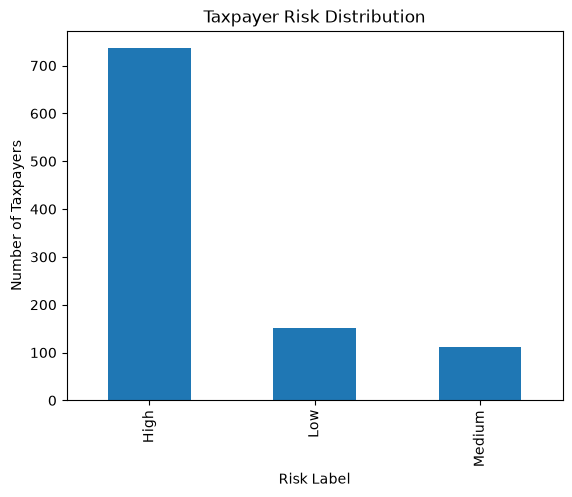

In [11]:
df["Risk_Label"].value_counts().plot(kind="bar")

plt.title("Taxpayer Risk Distribution")
plt.xlabel("Risk Label")
plt.ylabel("Number of Taxpayers")

plt.show()

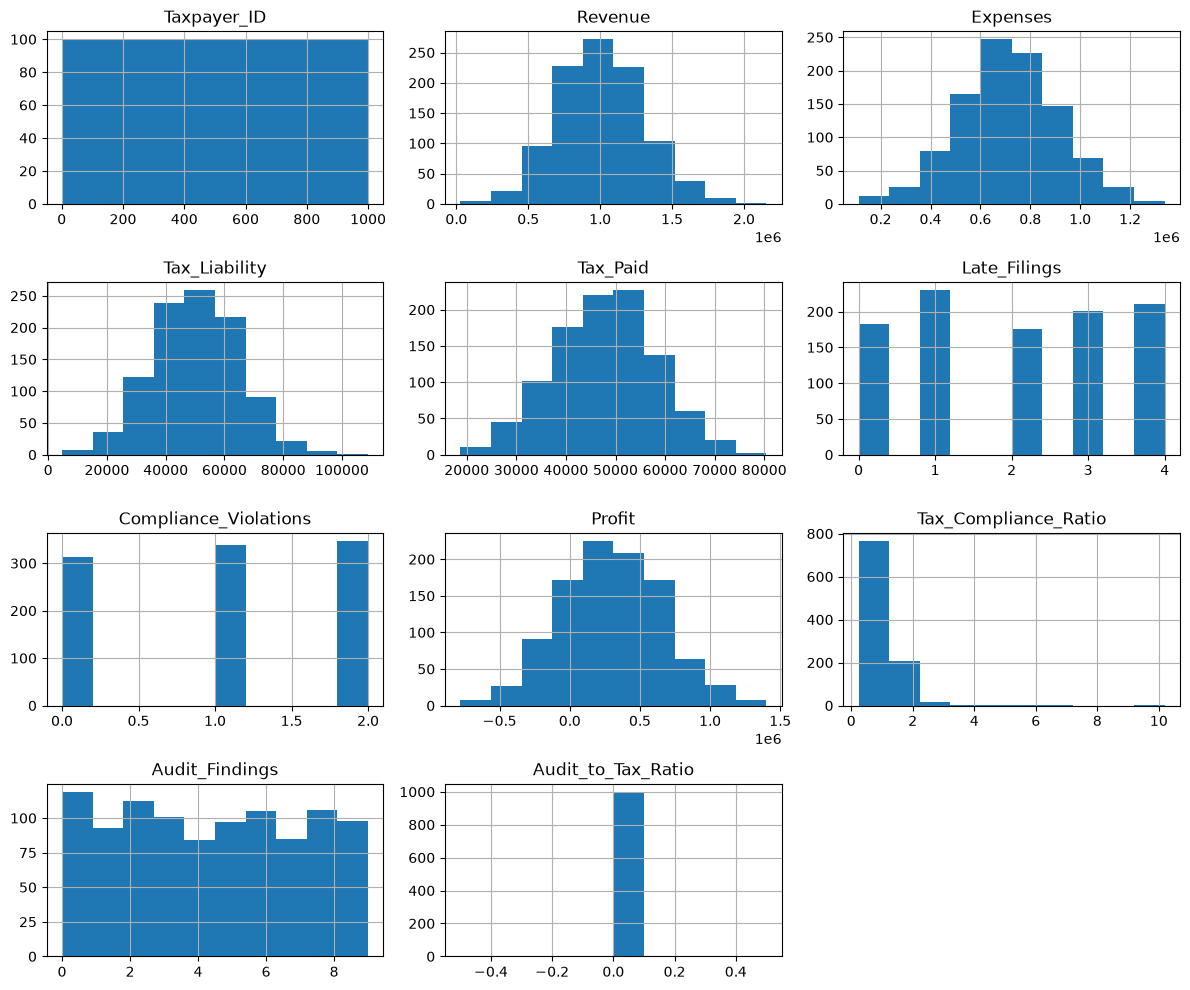

In [12]:
df.hist(figsize=(12, 10))

plt.tight_layout()
plt.show()

In [13]:
correlation = df.select_dtypes(include=np.number).corr()

correlation

,Taxpayer_ID,Revenue,Expenses,Tax_Liability,Tax_Paid,Late_Filings,Compliance_Violations,Profit,Tax_Compliance_Ratio,Audit_Findings,Audit_to_Tax_Ratio
Taxpayer_ID,1.000000,0.035484,-0.027804,0.019423,0.005470,-0.021339,0.029933,0.044154,0.006386,0.050369,NaN
Revenue,0.035484,1.000000,-0.040400,0.022129,-0.013321,0.009648,-0.001355,0.834452,-0.019228,-0.016619,NaN
Expenses,-0.027804,-0.040400,1.000000,-0.011199,-0.054698,0.010454,0.012212,-0.584343,-0.007839,-0.035514,NaN
Tax_Liability,0.019423,0.022129,-0.011199,1.000000,0.021586,0.004332,-0.018133,0.024149,-0.674905,-0.004945,NaN
Tax_Paid,0.005470,-0.013321,-0.054698,0.021586,1.000000,0.022385,0.003140,0.019349,0.348804,0.055467,NaN
Late_Filings,-0.021339,0.009648,0.010454,0.004332,0.022385,1.000000,0.007867,0.002070,0.026620,-0.013643,NaN
Compliance_Violations,0.029933,-0.001355,0.012212,-0.018133,0.003140,0.007867,1.000000,-0.007835,0.034075,-0.018119,NaN
Profit,0.044154,0.834452,-0.584343,0.024149,0.019349,0.002070,-0.007835,1.000000,-0.011293,0.006089,NaN
Tax_Compliance_Ratio,0.006386,-0.019228,-0.007839,-0.674905,0.348804,0.026620,0.034075,-0.011293,1.000000,0.036376,NaN
Audit_Findings,0.050369,-0.016619,-0.035514,-0.004945,0.055467,-0.013643,-0.018119,0.006089,0.036376,1.000000,NaN


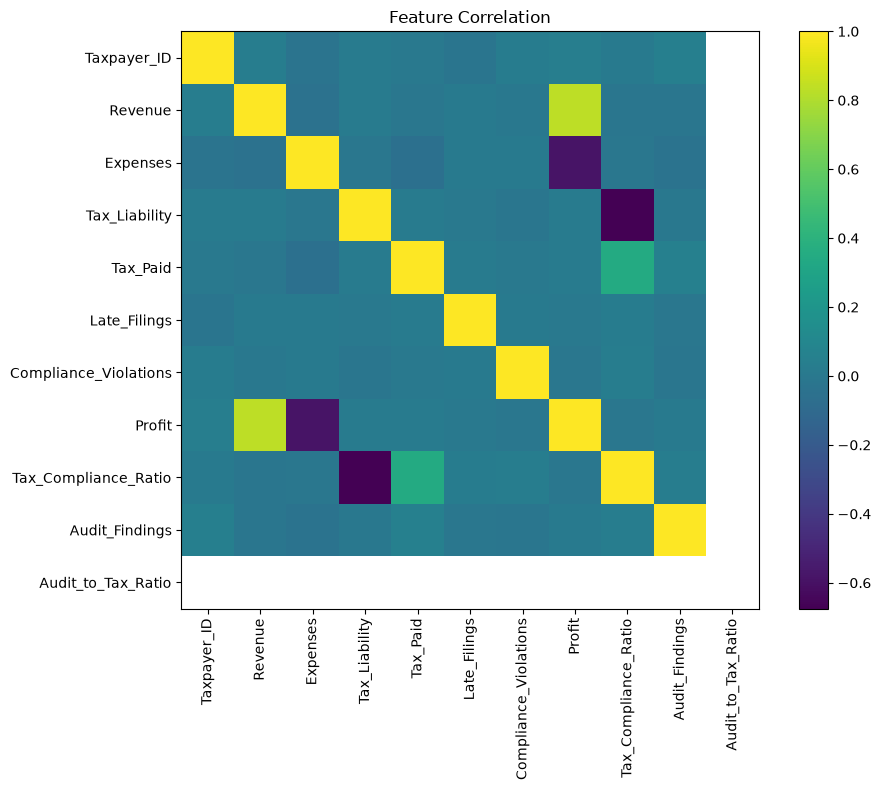

In [14]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation")

plt.tight_layout()
plt.show()

In [15]:
features = [
    "Revenue",
    "Expenses",
    "Tax_Liability",
    "Tax_Paid",
    "Late_Filings",
    "Compliance_Violations",
    "Profit",
    "Tax_Compliance_Ratio",
    "Audit_Findings"
]
X = df[features].copy()
y = df["Risk_Label"].copy()

In [16]:
X.head()

,Revenue,Expenses,Tax_Liability,Tax_Paid,Late_Filings,Compliance_Violations,Profit,Tax_Compliance_Ratio,Audit_Findings
0,1149014.25,979871.09,39872.33,28921.92,2,1,169143.16,0.73,0
1,958520.71,884926.74,47832.22,39396.15,1,1,73593.97,0.82,0
2,1194306.56,711926.07,38113.70,43863.94,4,0,482380.49,1.15,3
3,1456908.96,570612.64,45380.58,66876.88,4,2,886296.32,1.47,1
4,929753.99,839644.66,21595.78,53565.53,0,0,90109.33,2.48,2


In [17]:
y.head()

0      High
1    Medium
2      High
3      High
4       Low
Name: Risk_Label, dtype: str

In [18]:
y.unique()

<ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

In [19]:
df_binary = df[
    df["Risk_Label"].isin(["High", "Low"])
].copy()
df_binary["Risk_Label"].value_counts()

Risk_Label
High    736
Low     152
Name: count, dtype: int64

In [20]:
df_binary["Target"] = df_binary["Risk_Label"].map({
    "Low": 0,
    "High": 1
})

df_binary[["Risk_Label", "Target"]].head()

,Risk_Label,Target
0,High,1
2,High,1
3,High,1
4,Low,0
5,High,1


In [21]:
df_binary["Target"].value_counts()

Target
1    736
0    152
Name: count, dtype: int64

In [22]:
X = df_binary[features].copy()
y = df_binary["Target"].copy()

In [23]:
np.random.seed(42)

indices = np.random.permutation(len(X))

X = X.iloc[indices].reset_index(drop=True)
y = y.iloc[indices].reset_index(drop=True)

In [24]:
n = len(X)
train_size = int(0.60 * n)
val_size = int(0.20 * n)
test_size = n - train_size - val_size
print("Total:", n)
print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Total: 888
Train: 532
Validation: 177
Test: 179


In [25]:
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
y_val = y.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]
y_test = y.iloc[train_size + val_size:]

In [26]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)
print("Training:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training: (532, 9) (532,)
Validation: (177, 9) (177,)
Testing: (179, 9) (179,)
Training:
Target
1    437
0     95
Name: count, dtype: int64

Validation:
Target
1    152
0     25
Name: count, dtype: int64

Testing:
Target
1    147
0     32
Name: count, dtype: int64


In [27]:
mean = X_train.mean()
std = X_train.std()

In [28]:
X_train_scaled = (X_train - mean) / std
X_val_scaled = (X_val - mean) / std     
X_test_scaled = (X_test - mean) / std
X_train_scaled.head()

,Revenue,Expenses,Tax_Liability,Tax_Paid,Late_Filings,Compliance_Violations,Profit,Tax_Compliance_Ratio,Audit_Findings
0,1.131955,0.753021,1.685634,0.401842,1.316214,1.114324,0.491988,-0.602723,-1.520487
1,-1.626272,1.645250,1.875250,-0.365734,0.635723,-1.340418,-2.229424,-0.777854,-0.490917
2,-0.106265,1.009066,-0.543292,-0.578952,-0.725261,-1.340418,-0.649032,-0.135709,0.195464
3,0.229822,-0.884129,-1.229061,0.945306,-0.725261,1.114324,0.678871,1.104796,-0.834107
4,-0.135539,1.069122,0.492068,2.070942,-0.725261,1.114324,-0.706159,0.156174,-0.834107


In [29]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [30]:
test_values = np.array([-2, -1, 0, 1, 2])
sigmoid(test_values)

array([0.11920292, 0.26894142, 0.5       , 0.73105858, 0.88079708])

In [31]:
std

Revenue                  294235.060170
Expenses                 203803.725539
Tax_Liability             15608.189578
Tax_Paid                  10562.921323
Late_Filings                  1.469526
Compliance_Violations         0.814750
Profit                   365033.401671
Tax_Compliance_Ratio          0.685204
Audit_Findings                2.913837
dtype: float64

In [32]:
class LogisticRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.losses = []

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.losses = []

        for epoch in range(self.epochs):

            # 1. Weighted sum
            z = np.dot(X, self.weights) + self.bias

            # 2. Convert to probability
            predictions = sigmoid(z)

            # 3. Calculate error
            error = predictions - y

            # 4. Calculate gradients
            dw = np.dot(X.T, error) / len(X)
            db = np.mean(error)

            # 5. Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # 6. Calculate Binary Cross-Entropy loss
            loss = -np.mean(
                y * np.log(predictions + 1e-15) +
                (1 - y) * np.log(1 - predictions + 1e-15)
            )

            self.losses.append(loss)

    def predict_probability(self, X):

        X = np.asarray(X)

        z = np.dot(X, self.weights) + self.bias

        return sigmoid(z)

    def predict(self, X, threshold=0.5):

        probabilities = self.predict_probability(X)

        return (probabilities >= threshold).astype(int)

In [33]:
model = LogisticRegression(
    learning_rate=0.01,
    epochs=1000
)

In [34]:
model.fit(X_train_scaled, y_train)

In [35]:
model.weights


array([ 0.02584708,  0.09048057,  0.39344513, -0.34857423,  0.90575728,
        0.58956187, -0.02968265, -0.12473994, -0.03155929])

In [36]:
model.bias

np.float64(1.4196604896906513)

In [37]:
model.losses[:5]

[np.float64(0.6931471805599434),
 np.float64(0.6914215328418801),
 np.float64(0.6897049505820255),
 np.float64(0.6879973838299225),
 np.float64(0.6862987827540756)]

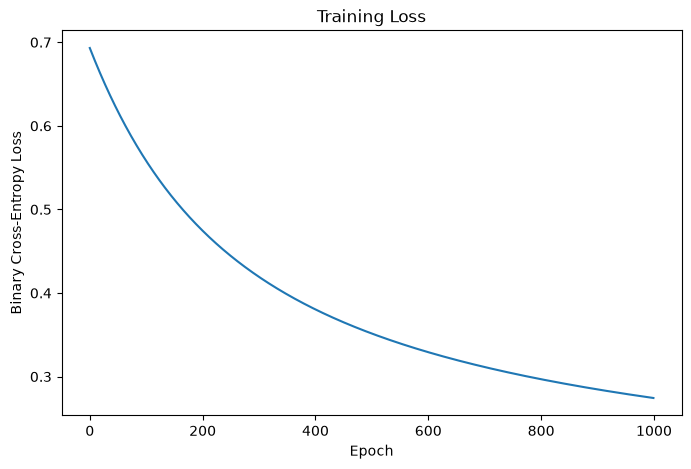

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(model.losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

In [39]:
val_probabilities = model.predict_probability(X_val_scaled)
val_probabilities[:10]

array([0.69687252, 0.94989365, 0.20843266, 0.96095422, 0.50302746,
       0.97091543, 0.82434126, 0.34335109, 0.322383  , 0.6818857 ])

In [40]:
val_predictions = model.predict(
    X_val_scaled,
    threshold=0.5
)
val_predictions[:10]

array([1, 1, 0, 1, 1, 1, 1, 0, 0, 1])

In [41]:
accuracy = np.mean(val_predictions == y_val.values)
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9265536723163842


In [42]:
actual = y_val.values
predicted = val_predictions
TN = np.sum((actual == 0) & (predicted == 0))
FP = np.sum((actual == 0) & (predicted == 1))
FN = np.sum((actual == 1) & (predicted == 0))
TP = np.sum((actual == 1) & (predicted == 1))
cm = np.array([
    [TN, FP],
    [FN, TP]
])
cm

array([[ 18,   7],
       [  6, 146]])

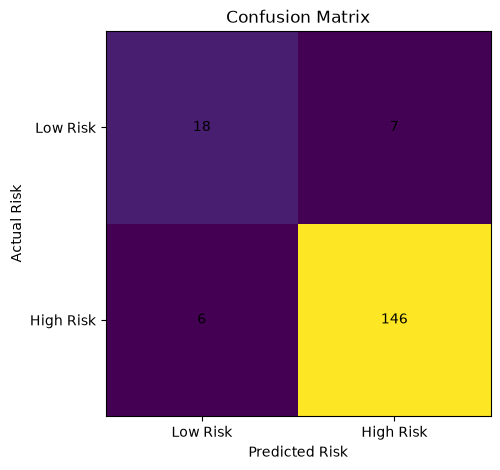

In [43]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.xticks([0, 1], ["Low Risk", "High Risk"])
plt.yticks([0, 1], ["Low Risk", "High Risk"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

In [44]:
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

print("Precision:", precision)
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

print("Recall:", recall)
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) != 0
    else 0
)

print("F1 Score:", f1)

Precision: 0.954248366013072
Recall: 0.9605263157894737
F1 Score: 0.9573770491803278


In [45]:
thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:

    predictions = model.predict(
        X_val_scaled,
        threshold=threshold
    )

    accuracy = np.mean(predictions == y_val.values)

    print("Threshold:", threshold)
    print("Accuracy:", accuracy)
    print()

Threshold: 0.3
Accuracy: 0.8983050847457628

Threshold: 0.5
Accuracy: 0.9265536723163842

Threshold: 0.7
Accuracy: 0.8531073446327684



In [46]:
# 1. Predict test data
test_predictions = model.predict(X_test)

# 2. Find wrong predictions
wrong_indices = np.where(
    test_predictions != y_test.values
)[0]

# 3. Count errors
print("Number of incorrect predictions:", len(wrong_indices))

Number of incorrect predictions: 32


In [47]:
error_analysis = X_test.iloc[wrong_indices].copy()
error_analysis["Actual"] = y_test.iloc[wrong_indices].values
error_analysis["Predicted"] = test_predictions[wrong_indices]
error_analysis

,Revenue,Expenses,Tax_Liability,Tax_Paid,Late_Filings,Compliance_Violations,Profit,Tax_Compliance_Ratio,Audit_Findings,Actual,Predicted
709,1057329.72,678539.57,27242.39,64147.79,0,1,378790.15,2.35,1,0,1
710,1277208.11,802781.57,59331.05,57331.28,1,0,474426.54,0.97,6,0,1
718,1039222.17,947218.64,48777.16,54464.90,1,1,92003.53,1.12,9,0,1
719,1250176.65,638158.18,38450.06,51163.58,1,1,612018.47,1.33,3,0,1
730,492260.61,796946.56,54448.63,53964.41,0,1,-304685.95,0.99,7,0,1
734,928315.59,556635.54,58233.26,65120.40,0,1,371680.05,1.12,2,0,1
741,965579.07,659283.93,58766.19,76684.03,1,0,306295.14,1.30,7,0,1
745,891710.15,817338.76,34749.75,53333.59,0,1,74371.39,1.53,7,0,1
753,682235.94,704254.32,39641.88,43863.84,1,1,-22018.38,1.11,0,0,1
757,858420.44,662942.47,40259.40,50837.51,0,0,195477.97,1.26,1,0,1


In [48]:

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_predictions
})

comparison.head(10)

,Actual,Predicted
0,0,1
1,0,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,0,1


In [49]:
correct = np.sum(y_test.values == test_predictions)
incorrect = np.sum(y_test.values != test_predictions)
print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)

Correct Predictions: 147
Incorrect Predictions: 32


In [50]:
test_accuracy = np.mean(test_predictions == y_test.values)
print("Model: Logistic Regression")
print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))
print("Test Samples:", len(X_test))
print("Number of Features:", X_train.shape[1])
print("Test Accuracy:", test_accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Model: Logistic Regression
Training Samples: 532
Validation Samples: 177
Test Samples: 179
Number of Features: 9
Test Accuracy: 0.8212290502793296
Precision: 0.954248366013072
Recall: 0.9605263157894737
F1 Score: 0.9573770491803278


In [51]:
results = X_test.copy()

results["Actual_Risk"] = y_test.values
results["Predicted_Risk"] = test_predictions

results.head()

,Revenue,Expenses,Tax_Liability,Tax_Paid,Late_Filings,Compliance_Violations,Profit,Tax_Compliance_Ratio,Audit_Findings,Actual_Risk,Predicted_Risk
709,1057329.72,678539.57,27242.39,64147.79,0,1,378790.15,2.35,1,0,1
710,1277208.11,802781.57,59331.05,57331.28,1,0,474426.54,0.97,6,0,1
711,1426151.27,900116.46,68269.39,44344.94,4,2,526034.81,0.65,5,1,1
712,838072.10,773457.46,38862.74,36003.02,4,1,64614.64,0.93,0,1,1
713,1736590.04,526765.03,37441.06,43370.60,1,2,1209825.01,1.16,7,1,1


In [52]:
import pickle

model_data = {
    "model": model,
    "mean": mean,
    "std": std,
    "features": features
}

with open("taxpayer_risk_model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Model saved successfully!")

Model saved successfully!
